# h-Selection Sweep (Step 2)

Runs over the 2018 TRAINING period only, on the modular dispatch pipeline (`dispatch_setup.setup_full_robust` / `dispatch_shared.py` / `dispatch_wrapper.py`).

For every day of 2018 and every `box_level`, and for `single-price`/`dual-price` "minimise total cost" (k=0) only: solve the robust layer with the BASELINE forecaster's inputs (B1 box from the same baseline), replay the REALISED 2018 prosumption through `realised_breakdown`, and record
- `total_charge_MWh`, `total_discharge_MWh` (realised, post-saturation control actions)
- `sat_hours` (saturation-block activation hours)
- `total_cost` (realised `C_da + C_imb` from the SAME `realised_breakdown` call, at the TRUE settlement prices for that day)

Then aggregate to the year and graph.

**DECISION vs SETTLEMENT price split (fixed this session)**: the decision solve (`solve_plain`) now uses the `_fc` proxy price columns (always >=0, exactly like `dfl_train_utils.py`/`eval_raw.py`), and only `realised_breakdown` (settlement) sees the true columns -- see `dispatch_shared.py`'s own module comment for why: a decision solve must never see the true (possibly negative) prices. This sweep used to load ONLY the 4 true columns and feed the SAME dict to both the decision and settlement -- a real leak, since `total_cost`'s new k=0 objective genuinely depends on `pi_da`/`pi_imb_up`/`pi_imb_down` (`dispatch_objectives.py`), so the old version let the decision see the future settlement price before committing to `p_da_rel`/the recourse policy. This was already true of every earlier run of this notebook (it affected `throughput`/`sat_hours` indirectly too), but matters far more now that `total_cost` -- the objective value itself -- is the plotted signal.

**Why these are the right signals**: control actions grow as the box widens (more recourse reserved) -> cost of a big box. `total_cost` is the direct economic signal for the cost of a narrow box -- it REPLACES the earlier `sat_MWh` (saturation volume) proxy, which turned out not to reliably track real economic outcomes: a standalone check (`box_level_econ_check.py`) found dual-price's `sat_MWh`/`sat_hours` strictly WORSENING as the box narrowed towards `(0.15, 0.85)`, while `total_cost`/`regret_v_oracle` strictly IMPROVED over the same range (that check went through `eval_raw.evaluate_one_pair`, which already had the fc/true split right, so it is NOT affected by the leak above) -- the narrower box's more aggressive recourse captures real economic value from active imbalance correction that a price-free volume proxy structurally cannot see. Tracking `total_cost` directly here removes that blind spot. `sat_hours` is kept alongside it (still informative about how often physical limits bind) but is no longer the deciding signal.

**gamma=0**: matches `eval_raw.py`'s own evaluation-stage gamma -- gamma's only justification is cvxpylayers' implicit-differentiation needing an invertible KKT system at TRAINING time, which doesn't apply to this plain forward Gurobi solve at all. See `eval_raw.py`'s own `GAMMA` constant comment for the full reasoning and the empirical check (`gamma_sweep_full_robust.py`) that backs it.

**k=1 (dispatchability) is no longer swept at all**, not just unplotted -- point_robust/dispatchability training was dropped entirely (see `dispatch_setup.py`'s module comment), `1stage` structurally can't support it, and `eval_raw.py` never evaluates it. The former `_assert_k1_price_free` correctness check (single==dual at k=1, since that mode is price-free by construction) is gone along with it -- there's no k=1 data left to check.

NO oracle, NO regret here -- both require a perfect-foresight oracle solve per day, which this sweep doesn't need: `total_cost` alone (not the gap to an oracle) is enough to see which box level is economically better. That oracle/regret comparison, when needed, lives in `eval_raw.py`/`aggregate_results.ipynb` instead.

**Run cost**: ~365 days x 7 box_levels x 2 corners ~= 5.1k small QP solves (Gurobi, T=24), plus 365 forecaster+sampler passes -- half the former run cost, now that k=1 is gone. Still genuinely slow in wall-clock terms (the ~10.2k-solve version of this took 30-50 minutes; expect roughly half that here) -- see `SKIP_SWEEP` below. Nothing here touches val/test.

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import torch
import cvxpy as cp
import pickle
import matplotlib.pyplot as plt

import sys
from pathlib import Path
from pyprojroot import here

ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
DATA_DIR = ROOT_DIR / "1_data" / "processed"
COPULA_DIR = ROOT_DIR / "5_scenario_gen"
MODEL_DIR = ROOT_DIR / "6_models"
PARAM_SWEEPS_DIR = MODEL_DIR / "param_sweeps"

sys.path.insert(0, str(FORECASTING_DIR))  # make forecasting module importable
sys.path.insert(0, str(COPULA_DIR))  # make copula module importable
sys.path.insert(0, str(MODEL_DIR))  # make dispatch_setup/dispatch_shared/dispatch_wrapper importable

from dispatch_setup import default_fixed_params, setup_full_robust as build_problem
from dispatch_shared import solve_plain, get_prices, select_fc_columns, cholesky_of_second_moment
from dispatch_wrapper import realised_breakdown
from forecasting import (reindex_and_impute, build_features, make_windows,
                             normalise_hist, normalise_exo, denormalise_y, Baseline_Forecaster,
                             HIST_COLS, FEAT_COLS, EXO_COLS)
from copula_lib import FrozenCopulaSampler

In [2]:
# ------------------------------------------------------------------ CONFIG
BOX_LEVELS = [(0.05, 0.95), (0.10, 0.90), (0.15, 0.85), (0.20, 0.80),
              (0.25, 0.75), (0.30, 0.70), (0.35, 0.65)]
CORNERS = [("single", 0.0), ("dual", 0.0)]   # k=0 ("minimise total cost") only -- k=1
                                              # (dispatchability) is no longer trained or
                                              # evaluated at all, see intro cell.
N_SCEN = 64
DT = 1.0
MIN_BOX = 1e-4
SOLVER = cp.GUROBI                       # plain solve; significantly faster than Clarabel
SAT_TOL = 1e-6
GAMMA = 0.0                              # matches eval_raw.py's evaluation-stage gamma -- see intro cell
LOCKED_IN_PICK = (0.15, 0.85)            # current deployed default (dfl_train_utils.py /
                                          # evaluate.py's own BOX_LEVELS constant)

# split boundaries (UTC); 2018 delivery blocks fully inside [TRAIN_START, VAL_START - 1h]
TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
VAL_START   = pd.Timestamp("2019-01-01 00:00:00+00:00")
ISSUE_HOUR  = 9
HORIZON     = 24
N_HIST      = 168

# PRICE_COLS: the 4 TRUE columns, used ONLY for settlement (realised_breakdown).
# PRICE_COLS_FC: the always->=0 forecast-proxy columns, used ONLY for the decision solve
# (solve_plain). Same split dfl_train_utils.py/eval_raw.py enforce -- see
# dispatch_shared.py's module comment: "every solver call that DECIDES decision
# variables... must be fed guaranteed->=0 prices, never the true (possibly negative)
# columns... true prices are reserved for settlement... never for a decision solve."
# This sweep used to load ONLY PRICE_COLS and feed the same true-price dict to BOTH the
# decision and settlement -- a real leak (true prices affect the k=0 objective directly,
# see dispatch_objectives.py's C_da/C_imb terms), now fixed.
PRICE_COLS = ["da", "imb", "imb_up", "imb_down"]
PRICE_COLS_FC = ["da_fc", "imb_fc", "imb_up_fc", "imb_down_fc"]
PRICE_COLS_ALL = PRICE_COLS + PRICE_COLS_FC

In [3]:
def mode_from_corner(price_model: str, k: float) -> str:
    """Maps this sweep's (price_model, k) corner notation onto the modular pipeline's
    `mode` selector. k is always 0.0 now (CORNERS only has k=0 entries) -- kept as a
    parameter rather than dropped so this still matches the (price_model, k) tuples
    CORNERS/run_sweep pass around, but there is no k=1/dispatchability branch anymore."""
    assert k == 0.0, f"only k=0 (\"minimise total cost\") is swept -- got k={k!r}"
    return f"{price_model}-price"

## Plug point

Return ONE day's quantiles as a torch (K=24, Q=19) tensor in PHYSICAL MW, from the FROZEN baseline forecaster.

In [4]:
def make_forecast_fn(model, scaler_stats, device, normalise_hist, denormalise_y):
    model.eval()

    def forecast_fn(x_hist_day, x_fut_day):
        with torch.no_grad():
            xh = normalise_hist(np.asarray(x_hist_day), scaler_stats)      # (n_hist, C_hist)
            xh = torch.as_tensor(xh, dtype=torch.float32, device=device).unsqueeze(0)
            xf = normalise_exo(np.asarray(x_fut_day), scaler_stats)
            xf = torch.as_tensor(xf, dtype=torch.float32, device=device).unsqueeze(0)
            q_norm = model(xh, xf)                                          # (1, K, Q) normalised
            q_phys = denormalise_y(q_norm, scaler_stats)                    # affine -> physical MW
        return q_phys.squeeze(0).to(torch.float64)                         # (K, Q)
    return forecast_fn

## Box (B1, from baseline)

In [5]:
def boxes_from_quantiles(quantiles, mean, quantile_levels, box_levels=BOX_LEVELS, min_box=MIN_BOX):
    """All box half-widths for one day, from the baseline quantiles + baseline mean anchor.
    Returns {box_level: (h_plus, h_minus)} as numpy."""
    q = quantiles.detach().cpu().numpy() if torch.is_tensor(quantiles) else np.asarray(quantiles)
    m = mean.detach().cpu().numpy() if torch.is_tensor(mean) else np.asarray(mean)
    levels = np.asarray(quantile_levels, float)
    out = {}
    for (lo, hi) in box_levels:
        i_lo = int(np.argmin(np.abs(levels - lo)))
        i_hi = int(np.argmin(np.abs(levels - hi)))
        h_plus = np.clip(q[:, i_hi] - m, min_box, None)
        h_minus = np.clip(m - q[:, i_lo], min_box, None)
        out[(lo, hi)] = (h_plus, h_minus)
    return out

## Per-day metric reduction

In [6]:
def _day_metrics(fp, bd):
    tn = lambda t: t.detach().cpu().numpy()
    pch_r, pdis_r = tn(bd.p_ch_r), tn(bd.p_dis_r)
    clip_ch = np.abs(tn(bd.p_ch_raw) - pch_r)
    clip_dis = np.abs(tn(bd.p_dis_raw) - pdis_r)
    return {
        "total_charge_MWh":    float((pch_r * fp.dt).sum()),
        "total_discharge_MWh": float((pdis_r * fp.dt).sum()),
        "sat_hours":           int(((clip_ch > SAT_TOL) | (clip_dis > SAT_TOL)).sum()),
        "total_cost":          float(bd.C_da + bd.C_imb),
    }

## The sweep

In [7]:
def run_sweep(windows, forecast_fn, sampler, quantile_levels):
    """windows: WindowSet with x_hist, x_fut, y, price, delivery_start for 2018.
    Returns (per_day_df, yearly_df). One fp, gamma=0 -- see CONFIG cell -- shared across
    both corners, since there's no longer a k=1 branch needing its own fp."""
    fp = default_fixed_params(num_scenarios=N_SCEN, gamma=GAMMA)
    bundles = {(pm, k): build_problem(fp, mode_from_corner(pm, k)) for pm, k in CORNERS}

    n_days = len(windows.delivery_start)
    rows = []
    for d in range(n_days):
        day = windows.delivery_start[d]
        if (d + 1) % 50 == 0 or d == 0:
            print(f"day {d + 1} of {n_days}", flush=True)

        realised = np.asarray(windows.y[d], float)                         # (T,) realised prosumption
        price_day = np.asarray(windows.price[d], float)                    # (T, 8): PRICE_COLS_ALL order

        # ONE forecaster + sampler pass per day (baseline is frozen; box-level/corner-independent)
        quantiles = forecast_fn(windows.x_hist[d], windows.x_fut[d])       # (K, Q) torch physical
        mean, xi = sampler.mean_and_errors(quantiles)                      # mean (T,), xi (N,T)
        mean_np = mean.detach().cpu().numpy()
        xi_np = xi.detach().cpu().numpy()
        Sigma = cholesky_of_second_moment(xi)
        Sigma_np = Sigma.detach().cpu().numpy() if torch.is_tensor(Sigma) else Sigma
        boxes = boxes_from_quantiles(quantiles, mean, quantile_levels)

        fc_price_day = select_fc_columns(price_day, cols=PRICE_COLS_ALL, real_cols=PRICE_COLS_FC)
        for pm, k in CORNERS:
            bundle = bundles[(pm, k)]
            # DECISION: fc proxy prices only, always >=0 -- never the true columns.
            fc_prices = get_prices(fc_price_day, pm, cols=PRICE_COLS)
            base_vals = {"pl_hat": mean_np, "Sigma_xi_chol": Sigma_np,
                         "xi_samples": xi_np, **fc_prices}                 # superset; solve_plain selects
            # SETTLEMENT: true prices, once the decision is already made.
            true_prices = get_prices(price_day, pm, cols=PRICE_COLS)
            for (lo, hi), (h_plus, h_minus) in boxes.items():
                vals = {**base_vals, "h_plus": h_plus, "h_minus": h_minus}
                out = solve_plain(bundle, vals, solver=SOLVER)
                bd = realised_breakdown(
                    fp, out["p_ch_hat"], out["p_dis_hat"], out["D_ch"], out["D_dis"],
                    out["p_da_rel"], realised=realised, pl_hat=mean_np, price_model=pm,
                    clip_recourse=True, **true_prices,
                )
                m = _day_metrics(fp, bd)
                rows.append({"price_model": pm, "k": int(k), "box_lo": lo, "box_hi": hi,
                             "delivery_start": day, **m})

    per_day = pd.DataFrame(rows)
    yearly = _aggregate(per_day)
    return per_day, yearly


def _aggregate(per_day: pd.DataFrame) -> pd.DataFrame:
    metrics = ["total_charge_MWh", "total_discharge_MWh", "sat_hours", "total_cost"]
    g = per_day.groupby(["price_model", "k", "box_lo", "box_hi"])
    agg = g[metrics].agg(["sum", "mean"])
    agg.columns = [f"{m}_{stat}" for m, stat in agg.columns]
    agg["n_days"] = g.size().values
    return agg.reset_index().sort_values(["price_model", "k", "box_lo"]).reset_index(drop=True)

## Main

Loads the frozen baseline forecaster + copula, builds the 2018 window set, and runs the sweep.

**`SKIP_SWEEP = True` by default**: once run for real, the results are cached to `h_sweep_per_day_2018.csv`/`h_sweep_yearly_2018.csv` in this directory -- loading them keeps re-execution of this notebook to seconds. Set `SKIP_SWEEP = False` (or delete the CSVs) to genuinely rerun the ~5,110-solve sweep from scratch. The CSVs from any earlier run (different corners/gamma) must be deleted before re-running with `SKIP_SWEEP = True`, or this will silently load stale, no-longer-matching data.

In [8]:
base = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
base = reindex_and_impute(base, HIST_COLS, freq="1h", warn_gap=6)
frame = build_features(base, feature_cols=FEAT_COLS, price_cols=PRICE_COLS_ALL)

windows = make_windows(
    frame, y_range=(TRAIN_START, VAL_START - pd.Timedelta(hours=1)),
    gate_aligned_only=True, issue_hour=ISSUE_HOUR,
    hist_cols=HIST_COLS, exo_cols=EXO_COLS, target_col="prosumption",
    price_cols=PRICE_COLS_ALL, n_hist=N_HIST, horizon=HORIZON,
)

SEED = 20240801
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| seed:", SEED, "| n_days in 2018 window set:", len(windows.delivery_start))

forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
model_config = forecaster_checkpoint["model_config"]
model = Baseline_Forecaster(**model_config)
model.load_state_dict(forecaster_checkpoint["state_dict"])
model.to(DEVICE)
model.eval()
sc = forecaster_checkpoint["scaler_stats"]
QUANTILE_LEVELS = forecaster_checkpoint["quantile_levels"]

cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
Z_corr = cop_bundle["Z_corr"]
levels = cop_bundle["quantile_levels"]
sampler = FrozenCopulaSampler(Z_corr, levels).to(DEVICE)
assert getattr(sampler, "S", N_SCEN) == N_SCEN, "sampler scenario count must equal N_SCEN"

forecast_fn = make_forecast_fn(model, sc, DEVICE, normalise_hist, denormalise_y)

[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
device: cpu | seed: 20240801 | n_days in 2018 window set: 365


In [9]:
SKIP_SWEEP = True   # flip to False (or delete the CSVs) to genuinely rerun the ~10,220-solve sweep

per_day_path = PARAM_SWEEPS_DIR / "h_sweep_per_day_2018.csv"
yearly_path = PARAM_SWEEPS_DIR / "h_sweep_yearly_2018.csv"

if SKIP_SWEEP and per_day_path.exists() and yearly_path.exists():
    per_day = pd.read_csv(per_day_path)
    yearly = pd.read_csv(yearly_path)
    print(f"loaded cached results: {per_day_path}, {yearly_path}")
else:
    per_day, yearly = run_sweep(windows, forecast_fn, sampler, QUANTILE_LEVELS)
    per_day.to_csv(per_day_path, index=False)
    yearly.to_csv(yearly_path, index=False)
    print(f"saved: {per_day_path} (per-day), {yearly_path} (yearly aggregate)")

pd.set_option("display.width", 140)
yearly.sort_values(["price_model", "k", "box_lo"]).reset_index(drop=True)

day 1 of 365


Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2828580


Academic license 2828580 - for non-commercial use only - registered to al___@ucl.ac.uk


...

day 250 of 365


day 300 of 365


day 350 of 365


saved: /home/fleet75/diss_bess/6_models/param_sweeps/h_sweep_per_day_2018.csv (per-day), /home/fleet75/diss_bess/6_models/param_sweeps/h_sweep_yearly_2018.csv (yearly aggregate)


,price_model,k,box_lo,box_hi,total_charge_MWh_sum,total_charge_MWh_mean,total_discharge_MWh_sum,total_discharge_MWh_mean,sat_hours_sum,sat_hours_mean,total_cost_sum,total_cost_mean,n_days
0,dual,0,0.05,0.95,3865.543304,10.590530,3507.463700,9.609490,711,1.947945,1.268565e+06,3475.521715,365
1,dual,0,0.10,0.90,3746.707002,10.264951,3401.952065,9.320417,1276,3.495890,1.266727e+06,3470.484158,365
2,dual,0,0.15,0.85,3641.532372,9.976801,3303.801885,9.051512,1947,5.334247,1.265679e+06,3467.614402,365
3,dual,0,0.20,0.80,3573.282853,9.789816,3251.982780,8.909542,2390,6.547945,1.269501e+06,3478.085947,365
4,dual,0,0.25,0.75,4074.697566,11.163555,3683.129808,10.090767,3786,10.372603,1.295888e+06,3550.377319,365
5,dual,0,0.30,0.70,4368.668876,11.968956,3923.932122,10.750499,4083,11.186301,1.306959e+06,3580.709137,365
6,dual,0,0.35,0.65,5681.635216,15.566124,4959.057847,13.586460,6008,16.460274,1.356383e+06,3716.118480,365
7,single,0,0.05,0.95,3491.534626,9.565848,3151.110000,8.633178,0,0.000000,1.148823e+06,3147.460125,365
8,single,0,0.10,0.90,3491.534626,9.565848,3151.110000,8.633178,0,0.000000,1.148823e+06,3147.460125,365
9,single,0,0.15,0.85,3491.534626,9.565848,3151.110000,8.633178,0,0.000000,1.148823e+06,3147.460125,365


## Results -- h-sweep elbow plots

Both `k=0` ("minimise total cost") corners -- the only modes actually trained/evaluated now, `1stage` single-price/dual-price -- are graphed below. `k=1` (dispatchability) is not swept at all any more (see this notebook's intro cell), so there is no k=1 data here to plot.

`total_cost` (mean per day) is the direct economic signal, and REPLACES `sat_MWh` in these plots -- see the intro cell for why: `sat_MWh` is a price-free volume proxy that turned out to point the wrong way relative to real cost. Control action (`throughput_MWh`) should GROW as the box widens (more recourse reserved); `sat_hours` should SHRINK. `total_cost` is shown directly rather than inferred from either -- currently locked in at `(0.15, 0.85)`, marked below on every panel.

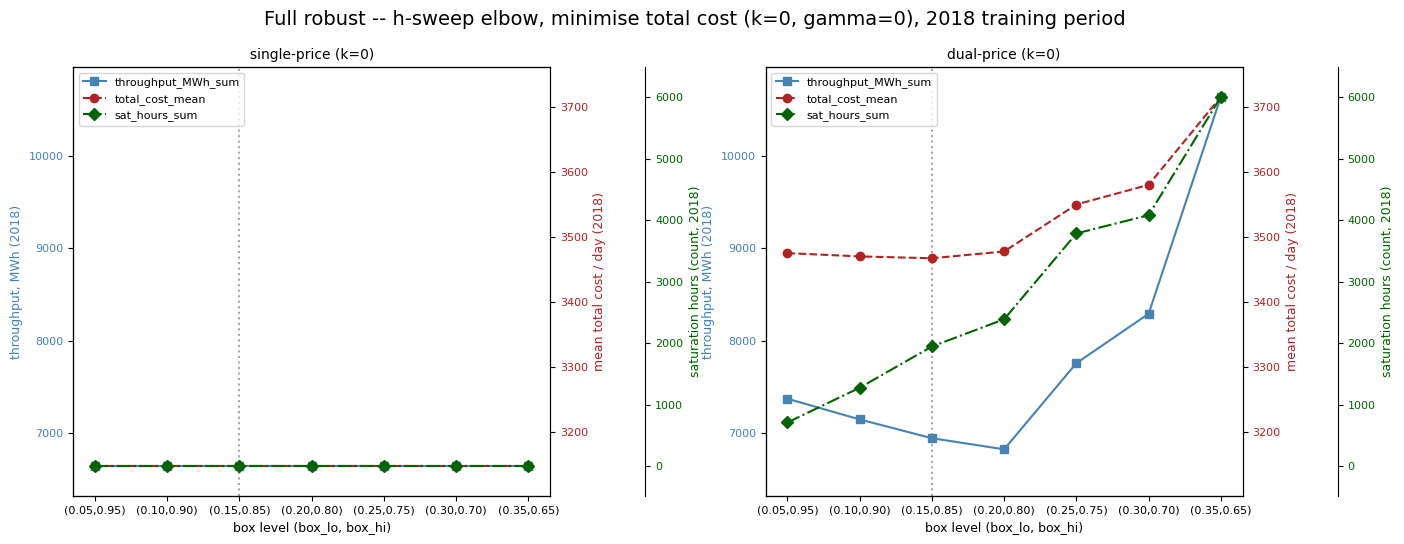

In [10]:
plot_spec = [
    ("single", 0),
    ("dual", 0),
]

# Compute GLOBAL min/max for each axis ACROSS BOTH panels, so the panels are directly
# visually comparable. throughput_MWh (MWh), total_cost_mean (mean total cost / day) and
# sat_hours (a count) are three different units -- each gets its own scale (total_cost
# has REPLACED sat_MWh here, so there is no longer an MWh pair to share a combined scale).
def _padded_range(values, pad_frac=0.08):
    lo, hi = float(np.min(values)), float(np.max(values))
    if hi == lo:
        return lo - 1.0, hi + 1.0
    pad = (hi - lo) * pad_frac
    return lo - pad, hi + pad

k0 = yearly[yearly["k"] == 0].copy()
k0["throughput_MWh_sum"] = k0["total_charge_MWh_sum"] + k0["total_discharge_MWh_sum"]

mwh_lim = _padded_range(k0["throughput_MWh_sum"])
cost_lim = _padded_range(k0["total_cost_mean"])
sat_hours_lim = _padded_range(k0["sat_hours_sum"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=False)
fig.suptitle("Full robust -- h-sweep elbow, minimise total cost (k=0, gamma=0), 2018 training period", fontsize=14)
fig.subplots_adjust(right=0.82, top=0.85, wspace=0.4)

for ax, (pm, k) in zip(axes.flat, plot_spec):
    sel = k0[(k0["price_model"] == pm) & (k0["k"] == k)].sort_values("box_lo")
    box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(sel["box_lo"], sel["box_hi"])]

    ax.plot(box_labels, sel["throughput_MWh_sum"], "s-", color="steelblue", label="throughput_MWh_sum")
    ax.set_ylabel("throughput, MWh (2018)", color="steelblue", fontsize=9)
    ax.set_ylim(*mwh_lim)
    ax.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("box level (box_lo, box_hi)", fontsize=9)
    ax.set_title(f"{pm}-price (k=0)", fontsize=10)

    ax2 = ax.twinx()
    ax2.plot(box_labels, sel["total_cost_mean"], "o--", color="firebrick", label="total_cost_mean")
    ax2.set_ylabel("mean total cost / day (2018)", color="firebrick", fontsize=9)
    ax2.set_ylim(*cost_lim)
    ax2.tick_params(axis="y", labelcolor="firebrick", labelsize=8)
    ax2.ticklabel_format(style="plain", axis="y")

    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("axes", 1.20))
    ax3.set_frame_on(True)
    ax3.patch.set_visible(False)
    ax3.plot(box_labels, sel["sat_hours_sum"], "D-.", color="darkgreen", label="sat_hours_sum")
    ax3.set_ylabel("saturation hours (count, 2018)", color="darkgreen", fontsize=9)
    ax3.set_ylim(*sat_hours_lim)
    ax3.tick_params(axis="y", labelcolor="darkgreen", labelsize=8)
    ax3.ticklabel_format(style="plain", axis="y")

    pick_label = f"({LOCKED_IN_PICK[0]:.2f},{LOCKED_IN_PICK[1]:.2f})"
    if pick_label in box_labels:
        ax.axvline(box_labels.index(pick_label), color="gray", linestyle=":", alpha=0.7)

    lines, labels = [], []
    for a in [ax, ax2, ax3]:
        h, l = a.get_legend_handles_labels()
        lines.extend(h)
        labels.extend(l)
    ax.legend(lines, labels, fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

### Focused view: dual-price (k=0, gamma=0)

single-price (k=0) shows essentially no box-level sensitivity at all -- `total_charge_MWh_sum` is identical to several significant figures across every box level, and `sat_hours_sum` stays at (or extremely close to) 0 until the box is absurdly narrow. dual-price is the only mode where box level actually does anything, so it's the one worth a focused view. `throughput_MWh_sum` is the "cost" of a wide box (more recourse action reserved/used); `total_cost_mean` (mean total cost per day) is the direct economic cost, shown here instead of the `sat_MWh` volume proxy it replaced -- see the intro cell. The elbow is where widening the box stops buying much economic improvement relative to the extra action it costs.

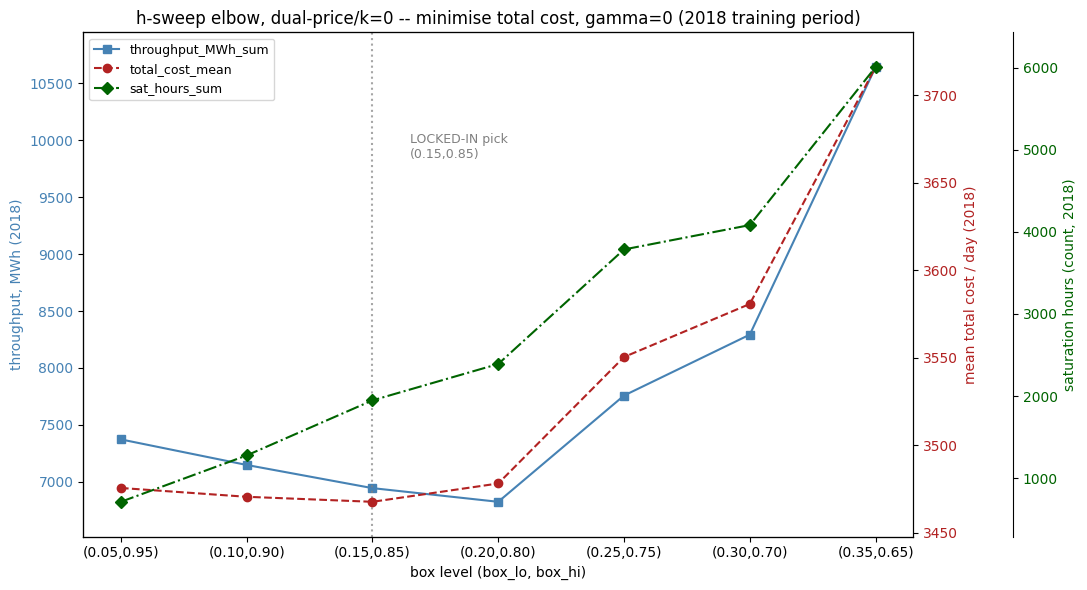

In [11]:
focus = yearly[(yearly["k"] == 0) & (yearly["price_model"] == "dual")].sort_values("box_lo").copy()
focus["throughput_MWh_sum"] = focus["total_charge_MWh_sum"] + focus["total_discharge_MWh_sum"]
box_labels = [f"({lo:.2f},{hi:.2f})" for lo, hi in zip(focus["box_lo"], focus["box_hi"])]

mwh_lim = _padded_range(focus["throughput_MWh_sum"])
cost_lim = _padded_range(focus["total_cost_mean"])
sat_hours_lim = _padded_range(focus["sat_hours_sum"])

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(box_labels, focus["throughput_MWh_sum"], "s-", color="steelblue", label="throughput_MWh_sum")
ax1.set_ylabel("throughput, MWh (2018)", color="steelblue")
ax1.set_ylim(*mwh_lim)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xlabel("box level (box_lo, box_hi)")

ax2 = ax1.twinx()
ax2.plot(box_labels, focus["total_cost_mean"], "o--", color="firebrick", label="total_cost_mean")
ax2.set_ylabel("mean total cost / day (2018)", color="firebrick")
ax2.set_ylim(*cost_lim)
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.ticklabel_format(style="plain", axis="y")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(box_labels, focus["sat_hours_sum"], "D-.", color="darkgreen", label="sat_hours_sum")
ax3.set_ylabel("saturation hours (count, 2018)", color="darkgreen")
ax3.set_ylim(*sat_hours_lim)
ax3.tick_params(axis="y", labelcolor="darkgreen")

pick_label = f"({LOCKED_IN_PICK[0]:.2f},{LOCKED_IN_PICK[1]:.2f})"
pick_idx = box_labels.index(pick_label)
ax1.axvline(pick_idx, color="gray", linestyle=":", alpha=0.7)
ax2.annotate(
    f"LOCKED-IN pick\n{pick_label}",
    xy=(pick_idx, focus["total_cost_mean"].iloc[pick_idx]),
    xytext=(pick_idx + 0.3, cost_lim[0] + (cost_lim[1] - cost_lim[0]) * 0.75),
    fontsize=9,
    color="gray",
)

lines, labels = [], []
for a in [ax1, ax2, ax3]:
    h, l = a.get_legend_handles_labels()
    lines.extend(h)
    labels.extend(l)
ax1.legend(lines, labels, fontsize=9, loc="upper left")

plt.title("h-sweep elbow, dual-price/k=0 -- minimise total cost, gamma=0 (2018 training period)")
fig.tight_layout()
plt.show()